# 02 — Exploratory Data Analysis
Deep-dive into the merged corpus: volume trends, headline length distributions, ticker coverage, and temporal gaps.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

ROOT  = Path('..')
PROC  = ROOT / 'data' / 'processed'
PLOTS = ROOT / 'results' / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC / 'all_banking_news.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} articles  |  {df.date.min().date()} → {df.date.max().date()}')
df.head(3)

Loaded 13,649 articles  |  2022-02-07 → 2026-03-24


,ticker,date,source,headline,text
0,SBIN,2022-02-07,moneycontrol,What should investors do with SBI after Q3 res...,NaN
1,SBIN,2022-02-08,moneycontrol,SBI Consolidated December 2021 Net Interest In...,NaN
2,SBIN,2022-02-08,moneycontrol,SBI Standalone December 2021 Net Interest Inco...,NaN


## 1. Basic stats

In [2]:
print('Shape:', df.shape)
print('\nNull counts:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Shape: (13649, 5)

Null counts:
ticker         0
date          15
source         0
headline       0
text        2918
dtype: int64

Data types:
ticker                 str
date        datetime64[us]
source                 str
headline               str
text                   str
dtype: object


## 2. Article volume over time

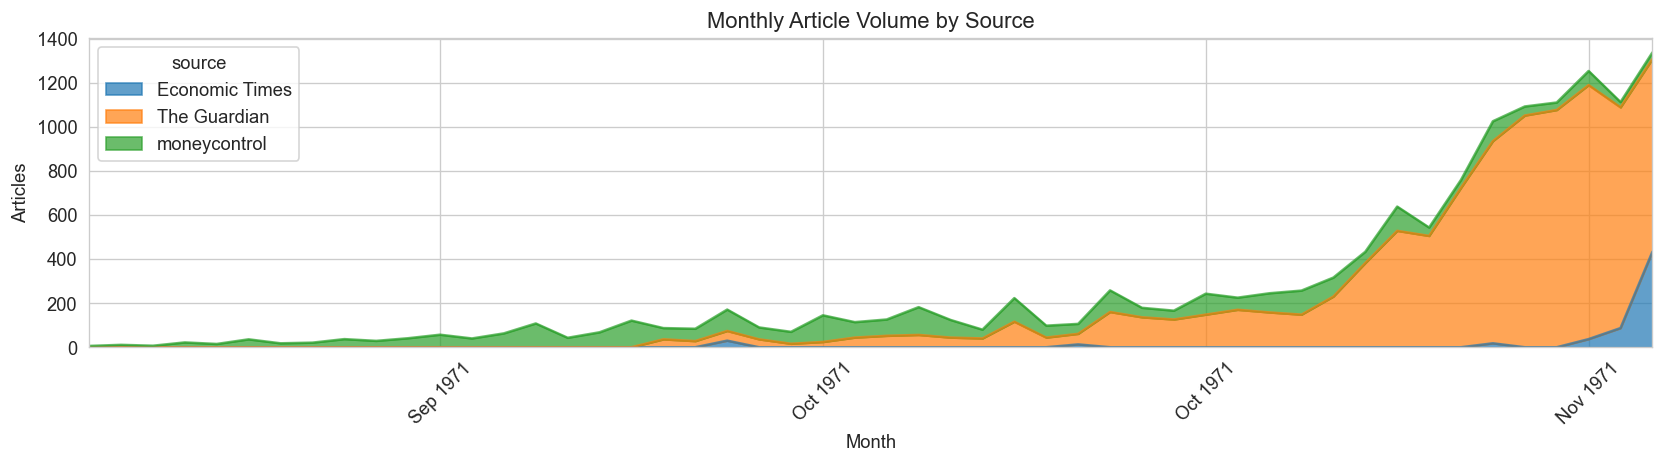

In [3]:
monthly = df.groupby([df['date'].dt.to_period('M'), 'source']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
ax.set_title('Monthly Article Volume by Source')
ax.set_xlabel('Month'); ax.set_ylabel('Articles')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS / 'volume_over_time.png')
plt.show()

## 3. Article count per ticker

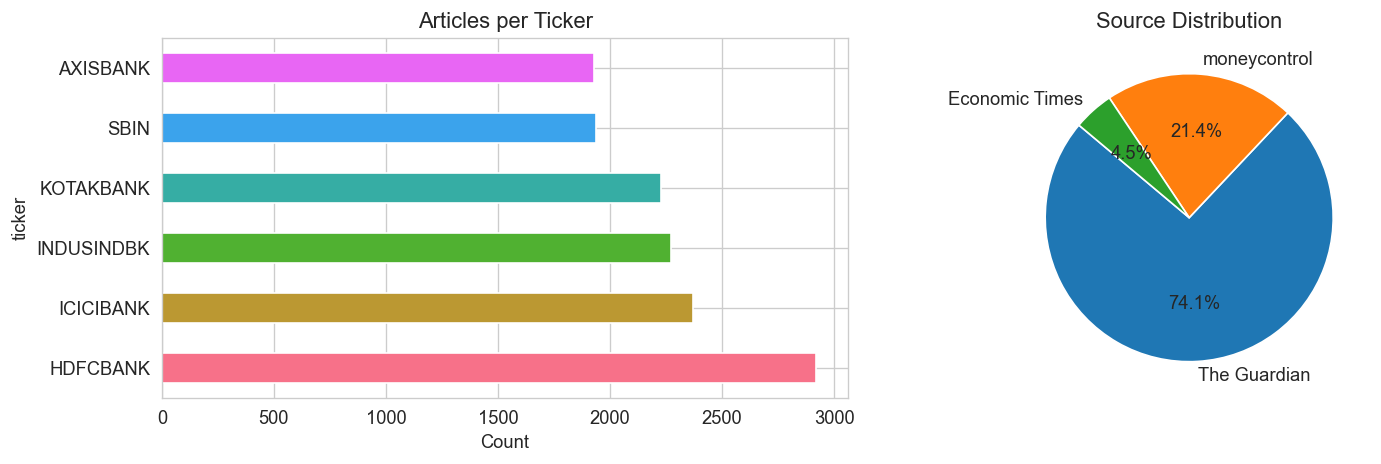

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tc = df['ticker'].value_counts()
tc.plot(kind='barh', ax=axes[0], color=sns.color_palette('husl', len(tc)))
axes[0].set_title('Articles per Ticker')
axes[0].set_xlabel('Count')

src = df['source'].value_counts()
src.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Source Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(PLOTS / 'ticker_source_dist.png')
plt.show()

## 4. Headline length distribution

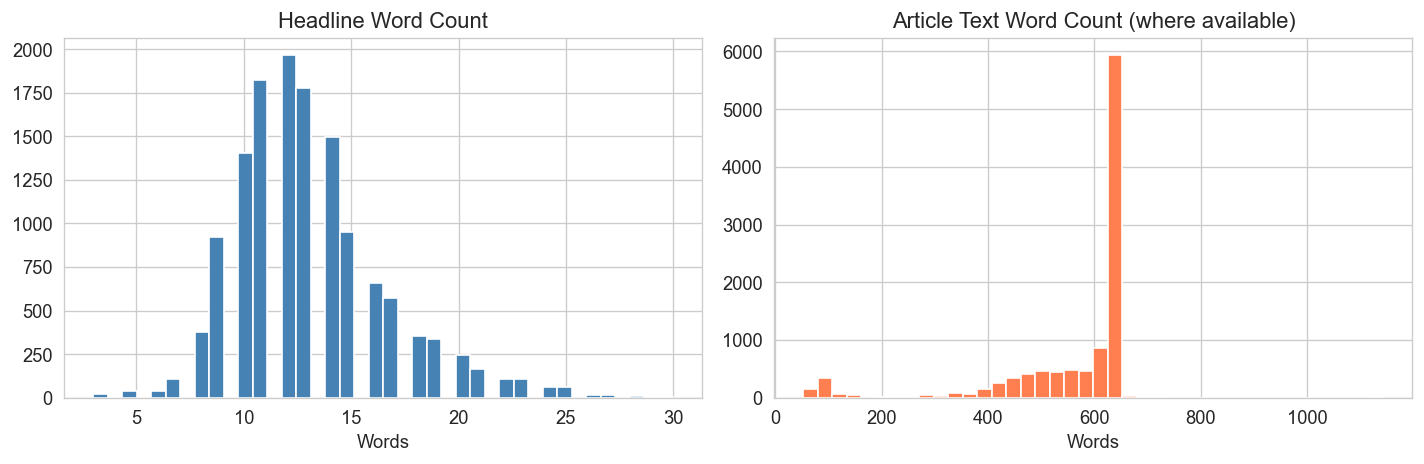

       headline_len      text_len
count  13649.000000  13649.000000
mean      13.118104    438.963294
std        3.471788    259.546964
min        3.000000      0.000000
25%       11.000000    104.000000
50%       13.000000    601.000000
75%       15.000000    631.000000
max       30.000000   1144.000000


In [5]:
df['headline_len'] = df['headline'].str.split().str.len()
df['text_len']     = df['text'].str.split().str.len().fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['headline_len'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Headline Word Count')
axes[0].set_xlabel('Words')

df[df['text_len'] > 0]['text_len'].hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Article Text Word Count (where available)')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.savefig(PLOTS / 'text_lengths.png')
plt.show()

print(df[['headline_len','text_len']].describe())

## 5. Day-of-week patterns

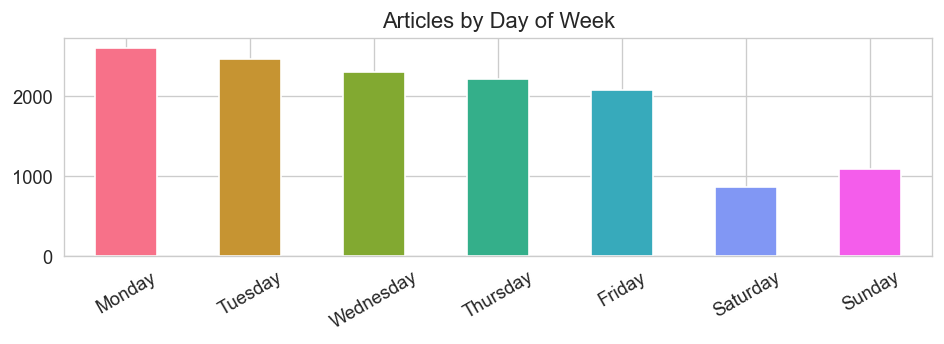

In [6]:
dow = df.groupby(df['date'].dt.day_name()).size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

fig, ax = plt.subplots(figsize=(8, 3))
dow.plot(kind='bar', ax=ax, color=sns.color_palette('husl', 7))
ax.set_title('Articles by Day of Week')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PLOTS / 'day_of_week.png')
plt.show()

## 6. Most common headline keywords

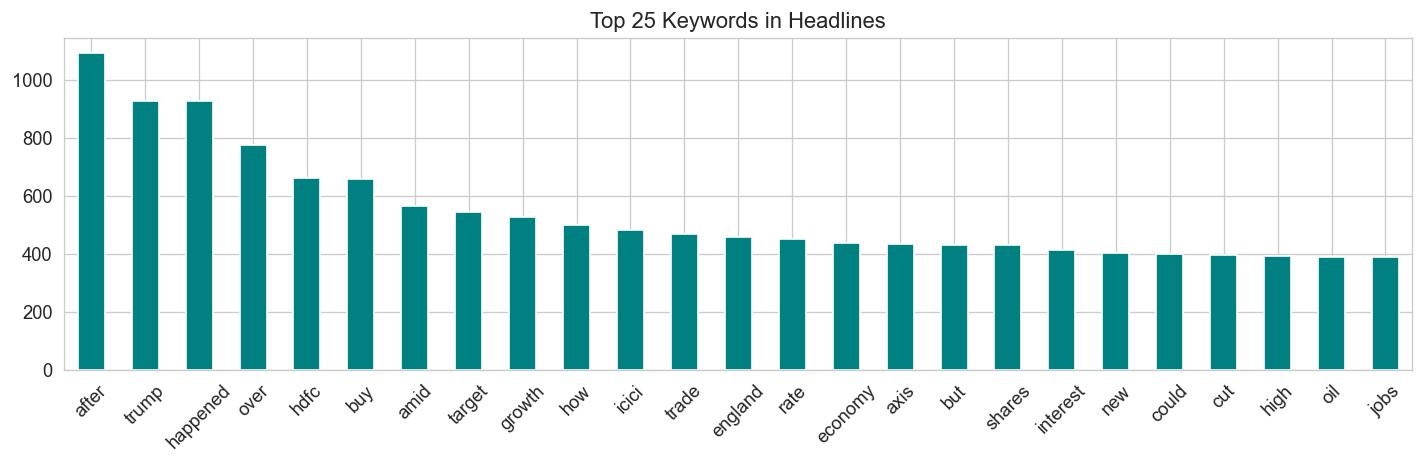

In [7]:
STOPWORDS = {'the','a','an','and','or','in','of','to','is','for','on','at','with',
             'as','its','by','from','has','be','that','this','it','are','was','will',
             'bank','banking','banks','india','indian',"'s",'rs','-','says','said'}

all_words = ' '.join(df['headline'].dropna()).lower()
tokens = re.findall(r'[a-z]+', all_words)
freq = Counter(t for t in tokens if t not in STOPWORDS and len(t) > 2)

top = pd.Series(dict(freq.most_common(25)))
fig, ax = plt.subplots(figsize=(12, 4))
top.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 25 Keywords in Headlines')
ax.set_xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS / 'top_keywords.png')
plt.show()